# Notebook 06 — Fashion-MNIST Compressed Sensing (Pixel Domain)

Following the professor's feedback:

> *"Image data such as MNIST and FashionMNIST are fine. Note that these are highly sparse
> in the pixel domain so you do not need DCT or wavelets."*

We apply compressed sensing **directly in pixel space**.  
FashionMNIST has a dark background (~60–70 % of pixels are zero), making pixel vectors
naturally sparse without any frequency transform.

**Signal model:**
$$b = A x + \varepsilon, \quad x \in [0,1]^{784}, \quad A \in \mathbb{R}^{m \times 784}$$

We compare ISTA, FISTA, LISTA, ALISTA, and HyperLISTA for measurement ratios
$m/d \in \{0.125, 0.25, 0.5\}$.

In [1]:
import sys, os, json, time
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.data.image_loader import build_pixel_cs_dataloaders
from src.models.ista import ISTA
from src.models.fista import FISTA
from src.models.lista import LISTA
from src.models.alista import ALISTA
from src.models.hyperlista import HyperLISTA
from src.training.trainer import train
from src.training.tuner import tune_hyperlista
from src.evaluation.metrics import psnr, ssim_batch, nmse_db, count_parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_DIR = '../results/checkpoints'
FIG_DIR  = '../results/images'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

print(f'Device: {device}')

Device: cuda


## 1. Pixel-Domain Sparsity Analysis

How sparse are FashionMNIST images in the pixel domain?

Fraction of near-zero pixels: 51.5%
Mean pixel value:             0.2542
Median pixel value:           0.0000


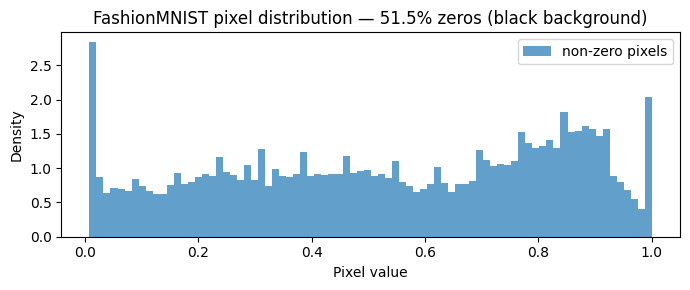

In [2]:
# Build a quick dataloader just to inspect sparsity
_, train_tmp, _ = build_pixel_cs_dataloaders(
    measurement_ratio=0.25, data_root='../data', device=device, seed=42
)
# Grab one batch
_b, x_sample = next(iter(train_tmp))
x_sample = x_sample  # (N, 784), values in [0, 1]

threshold = 1.0 / 255.0  # pixel < 1/255 treated as zero
frac_zero = (x_sample < threshold).float().mean().item()
print(f'Fraction of near-zero pixels: {frac_zero:.1%}')
print(f'Mean pixel value:             {x_sample.mean().item():.4f}')
print(f'Median pixel value:           {x_sample.median().item():.4f}')

# Histogram of pixel values
fig, ax = plt.subplots(figsize=(7, 3))
vals = x_sample.flatten().cpu().numpy()
ax.hist(vals[vals > threshold], bins=80, density=True, alpha=0.7, label='non-zero pixels')
ax.set_xlabel('Pixel value')
ax.set_ylabel('Density')
ax.set_title(f'FashionMNIST pixel distribution — {frac_zero:.1%} zeros (black background)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Evaluation Helper

In [3]:
@torch.no_grad()
def eval_pixel_cs(model, loader, device):
    """Evaluate NMSE, PSNR, SSIM on pixel-domain CS reconstruction."""
    model.eval()
    all_nmse, all_psnr, all_ssim = [], [], []
    for b, x_true in loader:
        b, x_true = b.to(device), x_true.to(device)
        x_hat = model(b).clamp(0.0, 1.0)   # pixel values in [0,1]
        err = ((x_hat - x_true)**2).sum(dim=-1)
        nrm = (x_true**2).sum(dim=-1).clamp(1e-12)
        all_nmse.append(10 * torch.log10((err / nrm).mean()).item())
        all_psnr.append(psnr(x_hat, x_true, max_val=1.0))
        all_ssim.append(ssim_batch(x_hat, x_true, H=28, W=28, data_range=1.0))
    return {
        'nmse_db': sum(all_nmse) / len(all_nmse),
        'psnr':    sum(all_psnr) / len(all_psnr),
        'ssim':    sum(all_ssim) / len(all_ssim),
    }


ALL_RESULTS = {}  # ratio -> {method: metrics}

## 3. Experiments Across Measurement Ratios

In [4]:
RATIOS  = [0.125, 0.25, 0.5]
K       = 16
N_EPOCH = 50

for ratio in RATIOS:
    d   = 784
    m   = int(ratio * d)
    tag = str(ratio).replace('0.', '')
    print(f'\n========== Ratio {ratio}  (m={m}) ==========')

    A, train_loader, test_loader = build_pixel_cs_dataloaders(
        measurement_ratio=ratio, sigma=0.0,
        batch_size=256, data_root='../data',
        device=device, seed=42,
    )
    results = {}

    # ── ISTA ────────────────────────────────────────────────────────────────
    print('  ISTA...')
    ista = ISTA(A, n_iter=K, lam=0.01).to(device)
    res = eval_pixel_cs(ista, test_loader, device)
    results['ISTA'] = res
    print(f'    NMSE={res["nmse_db"]:.1f} dB  PSNR={res["psnr"]:.1f} dB  SSIM={res["ssim"]:.3f}')

    # ── FISTA ───────────────────────────────────────────────────────────────
    print('  FISTA...')
    fista = FISTA(A, n_iter=K, lam=0.01).to(device)
    res = eval_pixel_cs(fista, test_loader, device)
    results['FISTA'] = res
    print(f'    NMSE={res["nmse_db"]:.1f} dB  PSNR={res["psnr"]:.1f} dB  SSIM={res["ssim"]:.3f}')

    # ── LISTA ───────────────────────────────────────────────────────────────
    print('  LISTA (training)...')
    ckpt = f'{CKPT_DIR}/lista_pixel_{tag}.pt'
    torch.manual_seed(0)
    lista = LISTA(A, n_layers=K, tied=False).to(device)
    if os.path.exists(ckpt):
        lista.load_state_dict(torch.load(ckpt, map_location=device))
        print('    Loaded from checkpoint.')
    else:
        train(lista, train_loader, test_loader,
              n_epochs=N_EPOCH, lr=1e-3, weight_decay=1e-5,
              device=device, patience=20, verbose=True)
        torch.save(lista.state_dict(), ckpt)
    res = eval_pixel_cs(lista, test_loader, device)
    results['LISTA'] = res
    print(f'    NMSE={res["nmse_db"]:.1f} dB  PSNR={res["psnr"]:.1f} dB  SSIM={res["ssim"]:.3f}')

    # ── ALISTA ──────────────────────────────────────────────────────────────
    print('  ALISTA (training)...')
    ckpt = f'{CKPT_DIR}/alista_pixel_{tag}.pt'
    alista = ALISTA(A, n_layers=K).to(device)
    if os.path.exists(ckpt):
        alista.load_state_dict(torch.load(ckpt, map_location=device))
        print('    Loaded from checkpoint.')
    else:
        train(alista, train_loader, test_loader,
              n_epochs=N_EPOCH, lr=5e-4, weight_decay=1e-5,
              device=device, patience=20, verbose=True)
        torch.save(alista.state_dict(), ckpt)
    res = eval_pixel_cs(alista, test_loader, device)
    results['ALISTA'] = res
    print(f'    NMSE={res["nmse_db"]:.1f} dB  PSNR={res["psnr"]:.1f} dB  SSIM={res["ssim"]:.3f}')

    # ── HyperLISTA ──────────────────────────────────────────────────────────
    print('  HyperLISTA (grid search)...')
    hp_path = f'{CKPT_DIR}/hyperlista_pixel_{tag}_hparams.json'
    if os.path.exists(hp_path):
        with open(hp_path) as f:
            hp = json.load(f)
        hyperlista = HyperLISTA(A, n_layers=K, c1=hp['c1'], c2=hp['c2'], c3=hp['c3']).to(device)
        print(f'    Loaded hparams: c1={hp["c1"]:.4f}, c2={hp["c2"]:.4f}, c3={hp["c3"]:.4f}')
    else:
        hyperlista = HyperLISTA(A, n_layers=K).to(device)
        hp = tune_hyperlista(hyperlista, val_loader=test_loader, device=device)
        with open(hp_path, 'w') as f:
            json.dump({'c1': hp['c1'], 'c2': hp['c2'], 'c3': hp['c3']}, f)
    res = eval_pixel_cs(hyperlista, test_loader, device)
    results['HyperLISTA'] = res
    print(f'    NMSE={res["nmse_db"]:.1f} dB  PSNR={res["psnr"]:.1f} dB  SSIM={res["ssim"]:.3f}')

    ALL_RESULTS[ratio] = results

print('\nAll experiments complete.')


========== Ratio 0.125  (m=98) ==========
  ISTA...
    NMSE=-1.1 dB  PSNR=8.0 dB  SSIM=0.063
  FISTA...
    NMSE=-1.1 dB  PSNR=8.0 dB  SSIM=0.063
  LISTA (training)...


Training: 100%|██████████| 50/50 [01:58<00:00,  2.38s/epoch, lr=1.00e-03, train_loss=0.0080, val_nmse=-12.29 dB]


    NMSE=-12.3 dB  PSNR=20.9 dB  SSIM=0.800
  ALISTA (training)...


Training: 100%|██████████| 50/50 [02:32<00:00,  3.04s/epoch, lr=5.00e-04, train_loss=0.2371, val_nmse=0.65 dB]                     


    NMSE=-0.3 dB  PSNR=7.2 dB  SSIM=0.054
  HyperLISTA (grid search)...
=== Stage 1: Coarse grid search ===


...

    NMSE=-3.3 dB  PSNR=10.0 dB  SSIM=0.299
  HyperLISTA (grid search)...
=== Stage 1: Coarse grid search ===


Coarse grid: 100%|██████████| 125/125 [00:03<00:00, 35.20it/s, best_nmse=-2.46 dB]


Coarse best: c1=0.0100, c2=0.0050, c3=0.5000  NMSE=-2.46 dB  (3.6s)

=== Stage 2: Fine grid search ===


Coarse grid: 100%|██████████| 343/343 [00:20<00:00, 17.02it/s, best_nmse=-2.84 dB]


Fine best:   c1=0.0033, c2=0.0017, c3=0.1667  NMSE=-2.84 dB  (20.2s)
    NMSE=-3.7 dB  PSNR=10.3 dB  SSIM=0.323

All experiments complete.


## 4. Results Tables

In [5]:
methods = ['ISTA', 'FISTA', 'LISTA', 'ALISTA', 'HyperLISTA']

for metric, label in [('psnr', 'PSNR (dB)'), ('ssim', 'SSIM'), ('nmse_db', 'NMSE (dB)')]:
    print(f'\n─── {label} ───')
    header = f'{"Method":<14}' + ''.join(f'{f"ratio={r}":>12}' for r in RATIOS)
    print(header)
    print('-' * (14 + 12 * len(RATIOS)))
    for method in methods:
        row = f'{method:<14}'
        for ratio in RATIOS:
            v = ALL_RESULTS.get(ratio, {}).get(method, {}).get(metric, float('nan'))
            row += f'{v:>12.3f}'
        print(row)


─── PSNR (dB) ───
Method         ratio=0.125  ratio=0.25   ratio=0.5
--------------------------------------------------
ISTA                 8.043       8.773      10.316
FISTA                8.003       8.722      10.469
LISTA               20.855      23.198      25.552
ALISTA               7.189       8.410       9.966
HyperLISTA           6.885       7.726      10.293

─── SSIM ───
Method         ratio=0.125  ratio=0.25   ratio=0.5
--------------------------------------------------
ISTA                 0.063       0.134       0.292
FISTA                0.063       0.135       0.315
LISTA                0.800       0.863       0.909
ALISTA               0.054       0.128       0.299
HyperLISTA           0.117       0.091       0.323

─── NMSE (dB) ───
Method         ratio=0.125  ratio=0.25   ratio=0.5
--------------------------------------------------
ISTA                -1.121      -1.877      -3.492
FISTA               -1.083      -1.838      -3.696
LISTA              -12.333    

## 5. Visual Comparison of Reconstructions

Reconstruction quality for ratio = 0.25 (m = 196 measurements from d = 784 pixels).

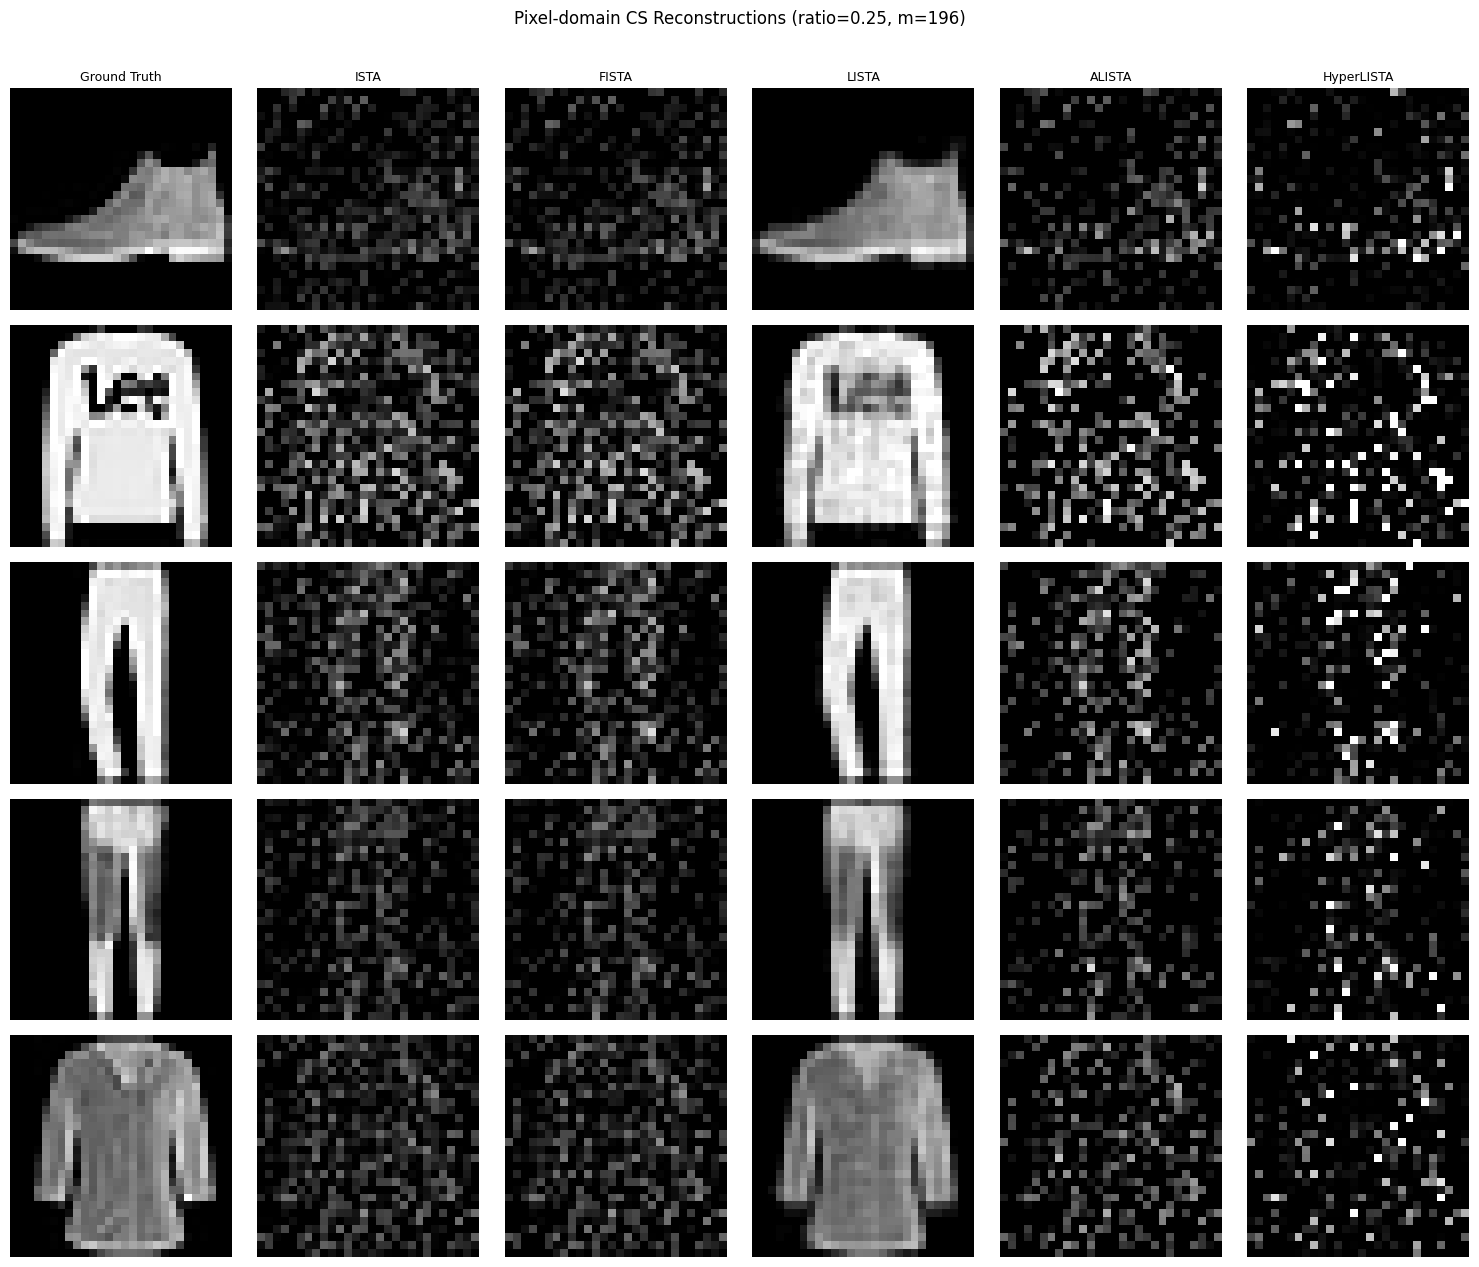

In [6]:
ratio_show = 0.25
tag_show   = str(ratio_show).replace('0.', '')

A_show, _, test_show = build_pixel_cs_dataloaders(
    measurement_ratio=ratio_show, data_root='../data', device=device, seed=42
)

# Load best models for this ratio
models_show = {
    'ISTA':   ISTA(A_show, n_iter=K, lam=0.01).to(device),
    'FISTA':  FISTA(A_show, n_iter=K, lam=0.01).to(device),
    'LISTA':  LISTA(A_show, n_layers=K, tied=False).to(device),
    'ALISTA': ALISTA(A_show, n_layers=K).to(device),
}
for name in ['LISTA', 'ALISTA']:
    ck = f'{CKPT_DIR}/{name.lower()}_pixel_{tag_show}.pt'
    if os.path.exists(ck):
        models_show[name].load_state_dict(torch.load(ck, map_location=device))

hp_path_show = f'{CKPT_DIR}/hyperlista_pixel_{tag_show}_hparams.json'
if os.path.exists(hp_path_show):
    with open(hp_path_show) as f:
        hp = json.load(f)
    models_show['HyperLISTA'] = HyperLISTA(A_show, n_layers=K,
                                            c1=hp['c1'], c2=hp['c2'], c3=hp['c3']).to(device)

# Get a batch
b_batch, x_true_batch = next(iter(test_show))
b_batch      = b_batch[:5].to(device)
x_true_batch = x_true_batch[:5].to(device)

n_images     = 5
method_names = list(models_show.keys())
n_methods    = len(method_names)

fig, axes = plt.subplots(n_images, n_methods + 1,
                         figsize=(2.5 * (n_methods + 1), 2.5 * n_images))

for i in range(n_images):
    # Ground truth
    ax = axes[i, 0]
    ax.imshow(x_true_batch[i].cpu().reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    if i == 0:
        ax.set_title('Ground Truth', fontsize=9)

    for j, (name, model) in enumerate(models_show.items()):
        with torch.no_grad():
            x_hat = model(b_batch[i:i+1]).clamp(0, 1)
        psnr_val = psnr(x_hat, x_true_batch[i:i+1], max_val=1.0)
        ax = axes[i, j + 1]
        ax.imshow(x_hat[0].cpu().reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if i == 0:
            ax.set_title(name, fontsize=9)
        ax.set_xlabel(f'{psnr_val:.1f} dB', fontsize=7)

fig.suptitle(f'Pixel-domain CS Reconstructions (ratio={ratio_show}, m={int(ratio_show*784)})', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pixel_cs_reconstructions_{tag_show}.pdf', bbox_inches='tight')
plt.show()

## 6. PSNR Bar Chart

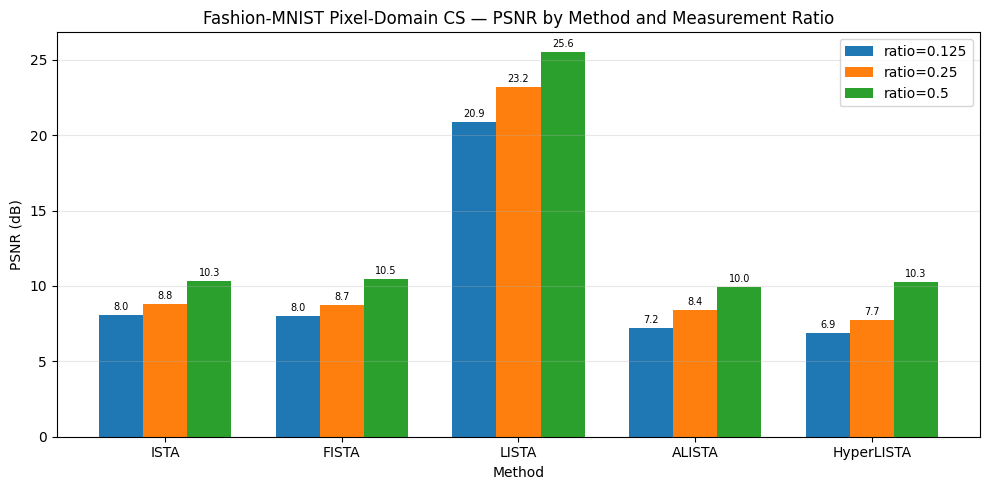

In [7]:
x = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, ratio in enumerate(RATIOS):
    vals = [ALL_RESULTS[ratio].get(m, {}).get('psnr', 0) for m in methods]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=f'ratio={ratio}')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Method')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Fashion-MNIST Pixel-Domain CS — PSNR by Method and Measurement Ratio')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pixel_cs_psnr_bars.pdf', bbox_inches='tight')
plt.show()